## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print("Data types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nRegions: {df['Region'].unique().tolist()}")
print(f"Models:  {df['Model'].unique().tolist()}")
print(f"Years:   {df['Year'].min()} to {df['Year'].max()}")

Data types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Missing values: 0

Regions: ['Europe', 'Asia', 'North America', 'Middle East']
Models:  ['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
Years:   2015 to 2025


In [4]:
df.describe().round(2)

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


## 3. Exploratory Data Analysis (EDA)

### 3.1 Annual Deliveries & CO2 Savings

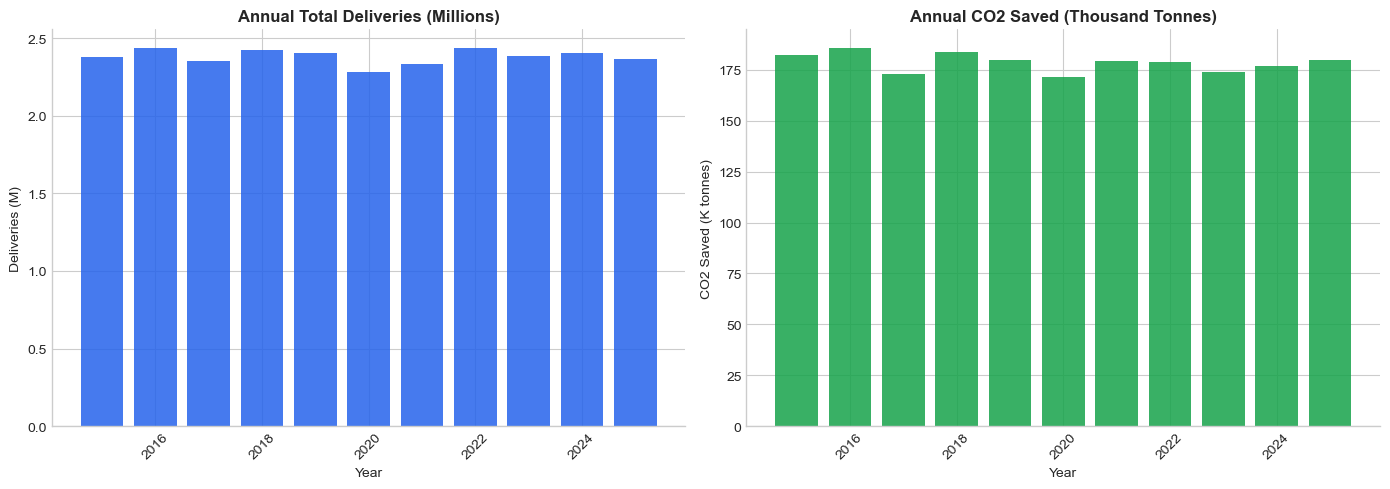

 Year  Deliveries  CO2_Saved
 2015     2375267  182466.15
 2016     2434081  185529.89
 2017     2350517  172837.26
 2018     2423104  183804.41
 2019     2404230  180034.13
 2020     2280336  171564.47
 2021     2335116  179127.01
 2022     2434220  178624.13
 2023     2382375  173875.07
 2024     2406899  176635.80
 2025     2368462  179864.93


In [5]:
yearly = df.groupby('Year').agg(
    Deliveries=('Estimated_Deliveries', 'sum'),
    CO2_Saved=('CO2_Saved_tons', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly['Year'], yearly['Deliveries']/1e6, color='#2563EB', alpha=0.85)
axes[0].set_title('Annual Total Deliveries (Millions)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deliveries (M)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(yearly['Year'], yearly['CO2_Saved']/1e3, color='#16A34A', alpha=0.85)
axes[1].set_title('Annual CO2 Saved (Thousand Tonnes)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('CO2 Saved (K tonnes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print(yearly.to_string(index=False))

### 3.2 Deliveries by Model and Region

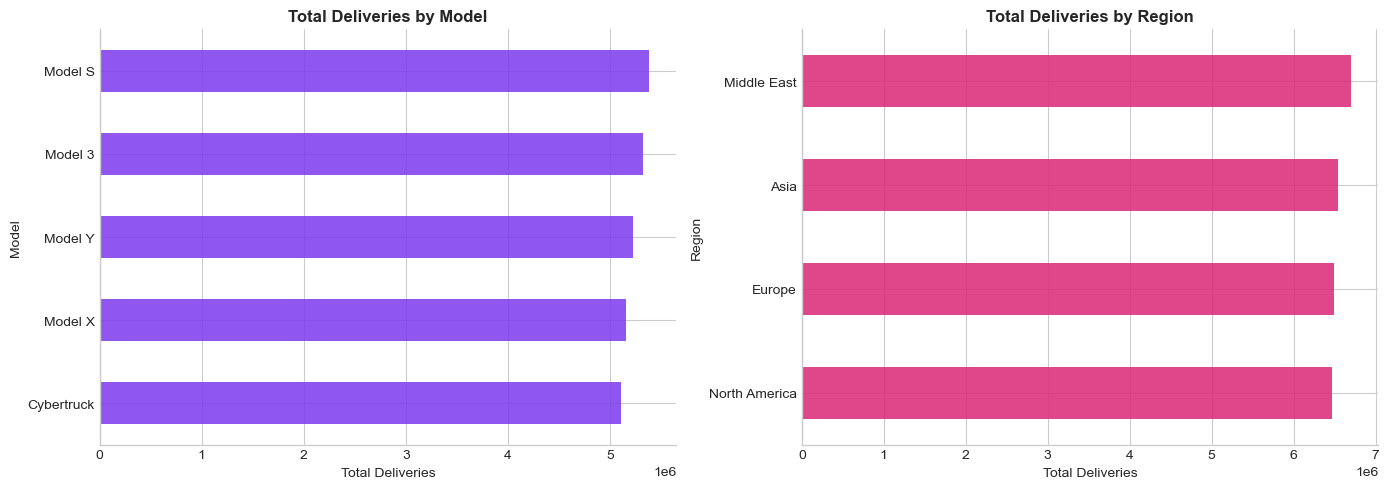

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=True)
model_del.plot(kind='barh', ax=axes[0], color='#7C3AED', alpha=0.85)
axes[0].set_title('Total Deliveries by Model', fontweight='bold')
axes[0].set_xlabel('Total Deliveries')

region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=True)
region_del.plot(kind='barh', ax=axes[1], color='#DB2777', alpha=0.85)
axes[1].set_title('Total Deliveries by Region', fontweight='bold')
axes[1].set_xlabel('Total Deliveries')

plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

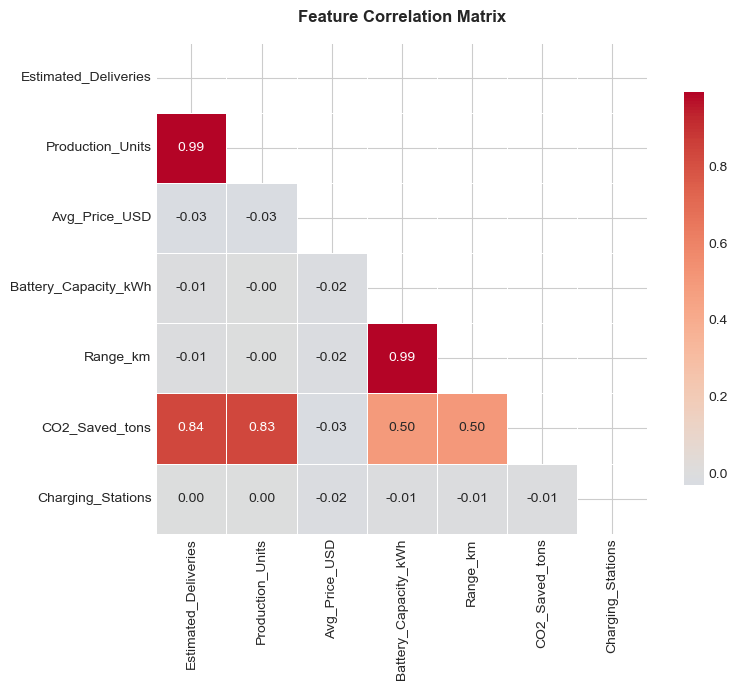

In [7]:
numeric_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 3.4 Distribution of Key Variables

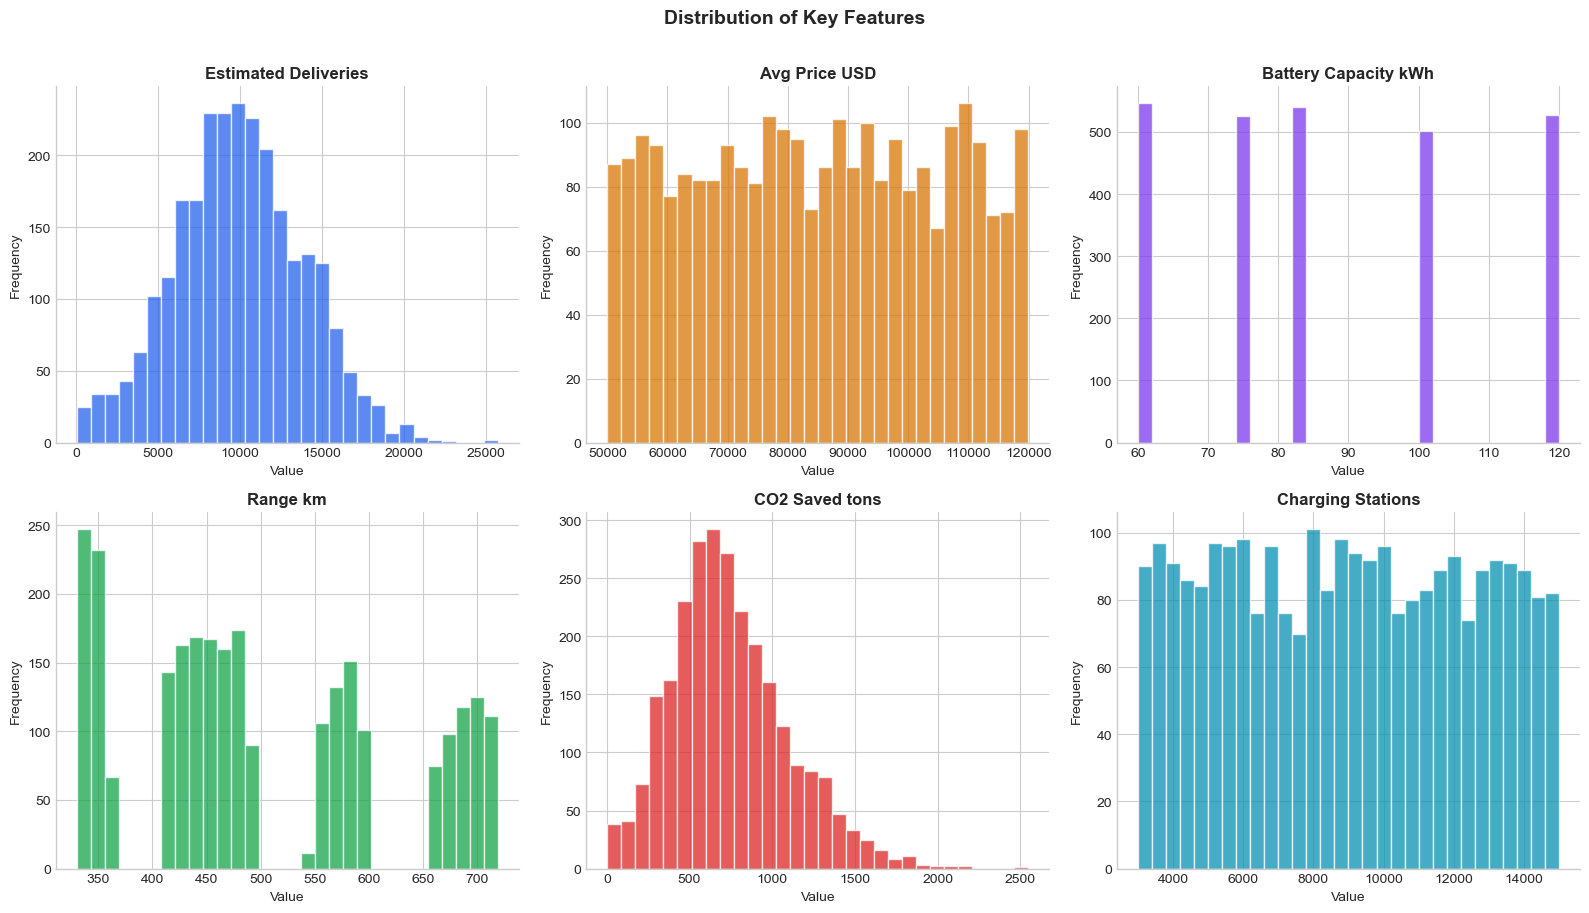

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_cols = ['Estimated_Deliveries', 'Avg_Price_USD', 'Battery_Capacity_kWh',
             'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
colors = ['#2563EB', '#D97706', '#7C3AED', '#16A34A', '#DC2626', '#0891B2']

for ax, col, color in zip(axes.flatten(), plot_cols, colors):
    ax.hist(df[col], bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Distribution of Key Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Average Price by Model Over Time

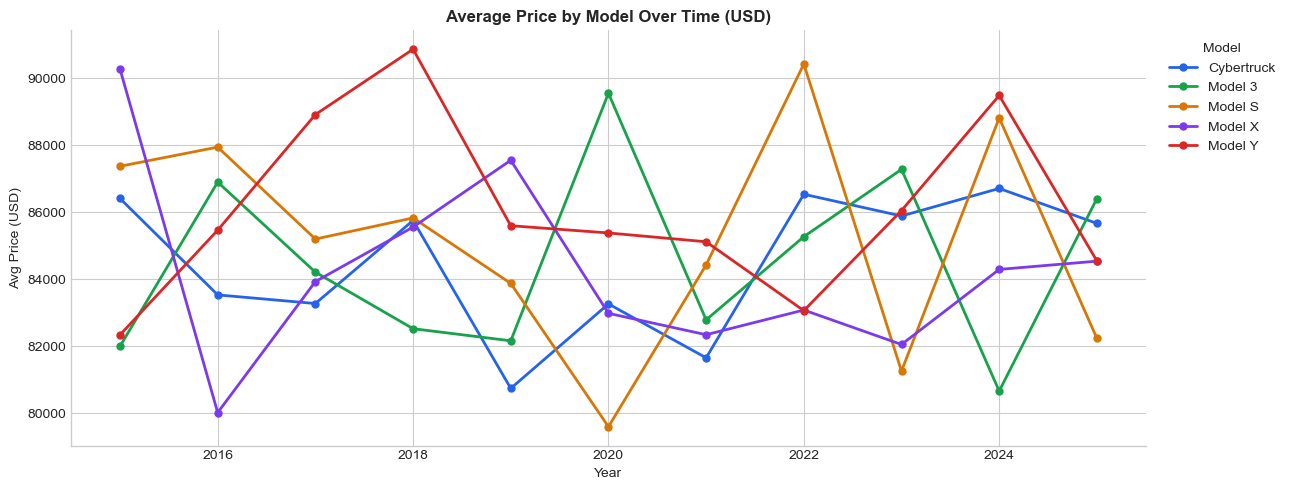

In [9]:
price_trend = df.groupby(['Year','Model'])['Avg_Price_USD'].mean().unstack()

plt.figure(figsize=(13, 5))
palette = ['#2563EB', '#16A34A', '#D97706', '#7C3AED', '#DC2626']
for model, color in zip(price_trend.columns, palette):
    plt.plot(price_trend.index, price_trend[model], marker='o', label=model,
             color=color, linewidth=2, markersize=5)

plt.title('Average Price by Model Over Time (USD)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Avg Price (USD)')
plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [10]:
# Date features
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df['Quarter'] = df['Date'].dt.quarter

# Derived ratio features
df['Production_Efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']
df['Revenue_Estimate']      = df['Estimated_Deliveries'] * df['Avg_Price_USD']
df['Range_per_kWh']         = df['Range_km'] / df['Battery_Capacity_kWh']
df['CO2_per_Delivery']      = df['CO2_Saved_tons'] / df['Estimated_Deliveries']

# Monotonic time index
df['YearMonth']  = df['Year'] * 12 + df['Month']
df['Time_Index'] = df['YearMonth'] - df['YearMonth'].min()

# Encode categoricals
le_region = LabelEncoder()
le_model  = LabelEncoder()
df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc']  = le_model.fit_transform(df['Model'])

new_cols = ['Quarter','Production_Efficiency','Revenue_Estimate',
            'Range_per_kWh','CO2_per_Delivery','Time_Index','Region_enc','Model_enc']
print("New engineered features:")
print(df[new_cols].describe().round(3))

New engineered features:
        Quarter  Production_Efficiency  Revenue_Estimate  Range_per_kWh  \
count  2640.000               2640.000      2.640000e+03       2640.000   
mean      2.500                  0.933      8.402867e+08          5.745   
std       1.118                  0.037      3.937252e+08          0.145   
min       1.000                  0.870      3.427300e+06          5.493   
25%       1.750                  0.900      5.672172e+08          5.617   
50%       2.500                  0.932      8.040993e+08          5.750   
75%       3.250                  0.964      1.073729e+09          5.867   
max       4.000                  1.000      2.417428e+09          5.992   

       CO2_per_Delivery  Time_Index  Region_enc  Model_enc  
count          2640.000    2640.000    2640.000   2640.000  
mean              0.075      65.500       1.500      2.000  
std               0.018      38.111       1.118      1.414  
min               0.049       0.000       0.000      0.

## 5. Regression Modelling - Predicting Deliveries

### 5.1 Train / Test Split & Scaling

In [11]:
FEATURES = ['Year','Month','Quarter','Time_Index','Region_enc','Model_enc',
            'Avg_Price_USD','Battery_Capacity_kWh','Range_km','Charging_Stations',
            'Production_Units','Range_per_kWh']

X = df[FEATURES]
y = df['Estimated_Deliveries']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {len(FEATURES)}")

Training samples : 2112
Test samples     : 528
Features         : 12


### 5.2 Train & Evaluate All Models

In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge'            : Ridge(alpha=1.0),
    'Lasso'            : Lasso(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    cv_r2  = cross_val_score(model, X_scaled, y, cv=5, scoring='r2').mean()
    results[name] = {'RMSE': round(rmse,2), 'MAE': round(mae,2),
                     'R2': round(r2,4), 'CV_R2': round(cv_r2,4)}

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print("=" * 60)
print(results_df.to_string())
print("=" * 60)

                     RMSE     MAE      R2   CV_R2
Linear Regression  417.60  340.42  0.9883  0.9884
Ridge              417.74  340.62  0.9883  0.9884
Lasso              417.32  340.27  0.9883  0.9884
Gradient Boosting  444.21  358.77  0.9868  0.9876
Random Forest      460.25  368.20  0.9858  0.9863


### 5.3 Model Comparison Chart

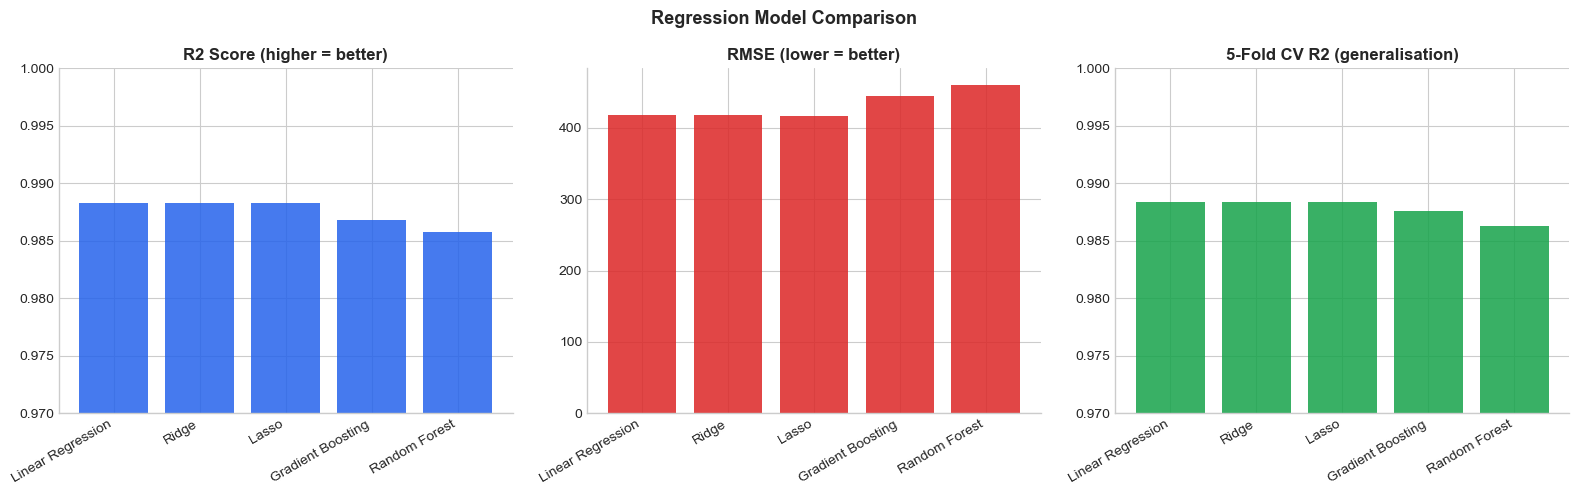

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = results_df.index.tolist()
x = np.arange(len(model_names))

axes[0].bar(x, results_df['R2'], color='#2563EB', alpha=0.85)
axes[0].set_title('R2 Score (higher = better)', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=30, ha='right')
axes[0].set_ylim(0.97, 1.0)

axes[1].bar(x, results_df['RMSE'], color='#DC2626', alpha=0.85)
axes[1].set_title('RMSE (lower = better)', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=30, ha='right')

axes[2].bar(x, results_df['CV_R2'], color='#16A34A', alpha=0.85)
axes[2].set_title('5-Fold CV R2 (generalisation)', fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(model_names, rotation=30, ha='right')
axes[2].set_ylim(0.97, 1.0)

plt.suptitle('Regression Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Actual vs Predicted - Best Model (Linear Regression)

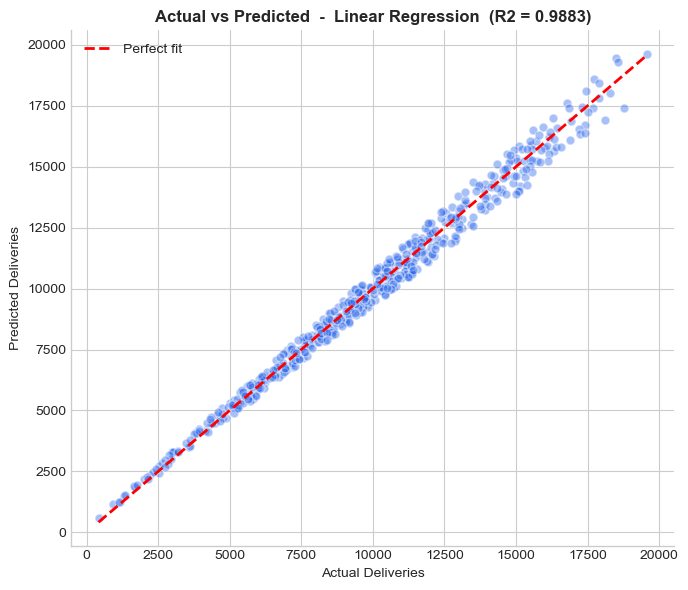

In [14]:
best_model   = models['Linear Regression']
y_pred_best  = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='#2563EB', edgecolors='white', s=40)
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect fit')
r2_val = r2_score(y_test, y_pred_best)
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title(f'Actual vs Predicted  -  Linear Regression  (R2 = {r2_val:.4f})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 5.5 Residual Analysis

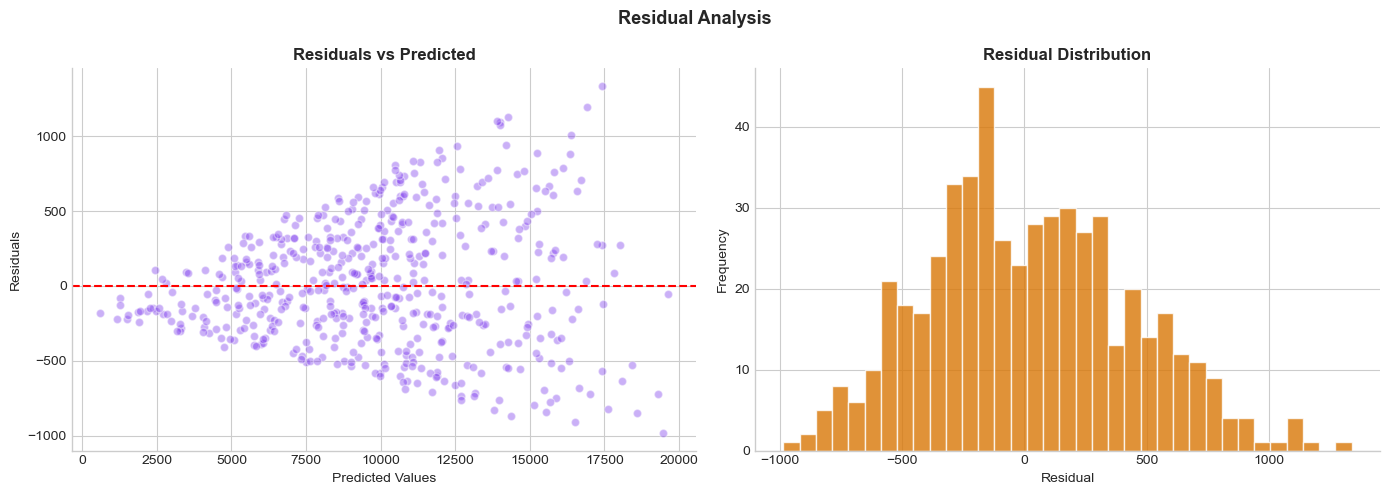

Mean residual : 14.94  (should be near 0)
Std residual  : 417.73


In [15]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.4, color='#7C3AED', edgecolors='white', s=35)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

axes[1].hist(residuals, bins=35, color='#D97706', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean residual : {residuals.mean():.2f}  (should be near 0)")
print(f"Std residual  : {residuals.std():.2f}")

### 5.6 Feature Importance - Random Forest

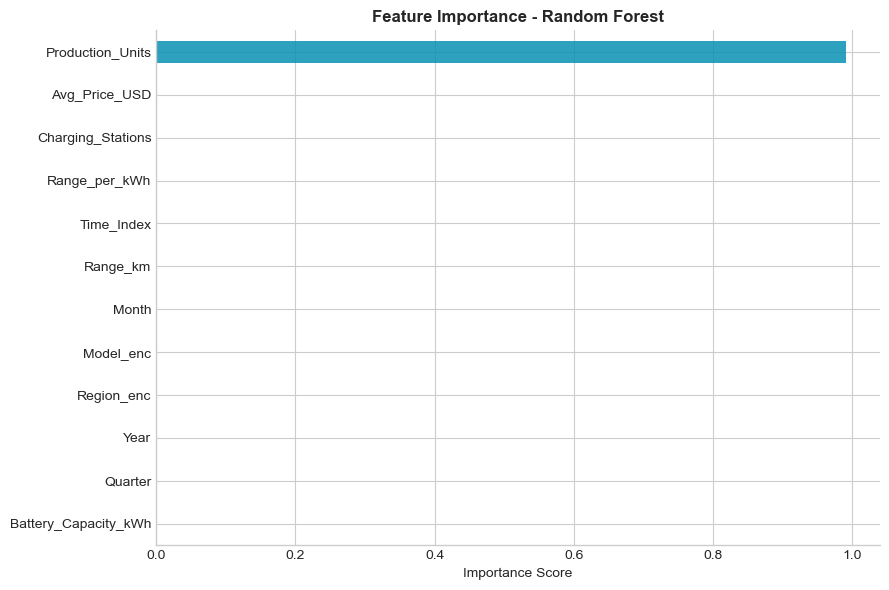

Top 5 features:
Production_Units     0.990905
Avg_Price_USD        0.001499
Charging_Stations    0.001359
Range_per_kWh        0.001344
Time_Index           0.001256


In [16]:
rf_model    = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='#0891B2', alpha=0.85)
plt.title('Feature Importance - Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.sort_values(ascending=False).head(5).to_string())

## 6. Hyperparameter Tuning - Gradient Boosting

In [17]:
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1]
}

gb_base     = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb_base, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV R2      : {grid_search.best_score_:.4f}")

best_gb    = grid_search.best_estimator_
y_pred_gb  = best_gb.predict(X_test)
print(f"Test R2 (tuned) : {r2_score(y_test, y_pred_gb):.4f}")
print(f"Test RMSE       : {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.2f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV R2      : 0.9872
Test R2 (tuned) : 0.9869
Test RMSE       : 441.70


In [18]:
cv_results = pd.DataFrame(grid_search.cv_results_)
param_cols = [c for c in cv_results.columns if 'param_' in c]
display_cols = param_cols + ['mean_test_score', 'std_test_score']
print("Grid Search Results (sorted by mean CV R2):")
print(cv_results[display_cols]
      .sort_values('mean_test_score', ascending=False)
      .round(4)
      .to_string(index=False))

Grid Search Results (sorted by mean CV R2):
 param_learning_rate  param_max_depth  param_n_estimators  mean_test_score  std_test_score
                0.05                3                 200           0.9872          0.0003
                0.05                3                 100           0.9871          0.0005
                0.10                3                 100           0.9870          0.0004
                0.10                3                 200           0.9866          0.0003
                0.05                5                 100           0.9865          0.0003
                0.10                5                 100           0.9862          0.0002
                0.05                5                 200           0.9862          0.0004
                0.10                5                 200           0.9856          0.0003


## 7. Time Series Analysis & Forecasting

### 7.1 Monthly Global Deliveries

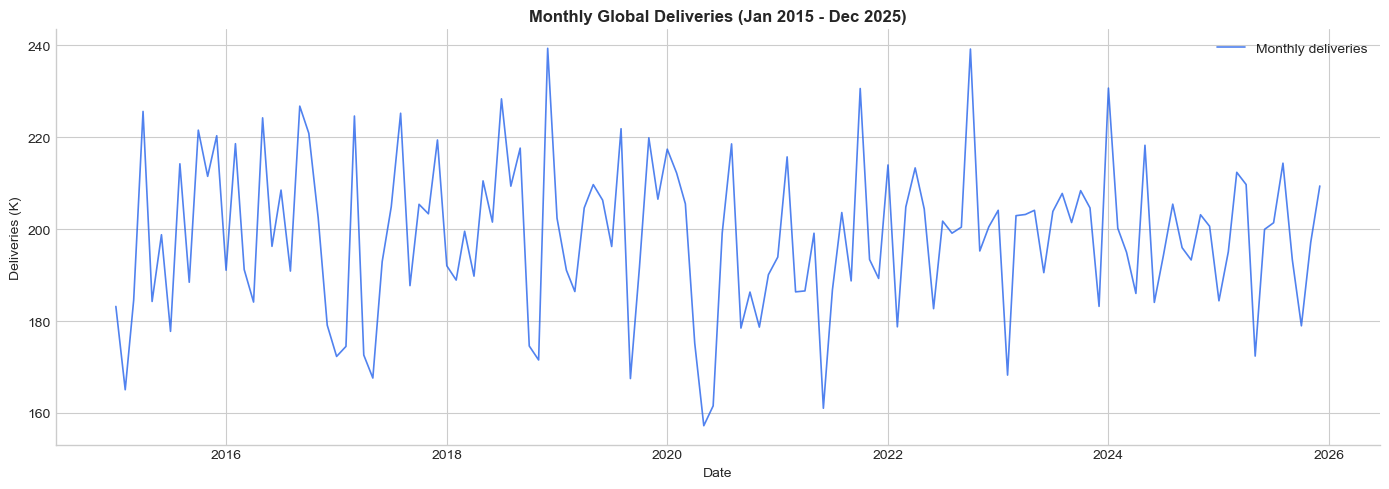

In [19]:
ts = (df.groupby(['Year','Month'])['Estimated_Deliveries']
        .sum()
        .reset_index()
        .sort_values(['Year','Month'])
        .reset_index(drop=True))
ts['t']      = np.arange(len(ts))
ts['Period'] = pd.to_datetime(ts[['Year','Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(ts['Period'], ts['Estimated_Deliveries']/1e3,
         color='#2563EB', linewidth=1.2, alpha=0.8, label='Monthly deliveries')
plt.title('Monthly Global Deliveries (Jan 2015 - Dec 2025)', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Deliveries (K)')
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Polynomial Trend Fit

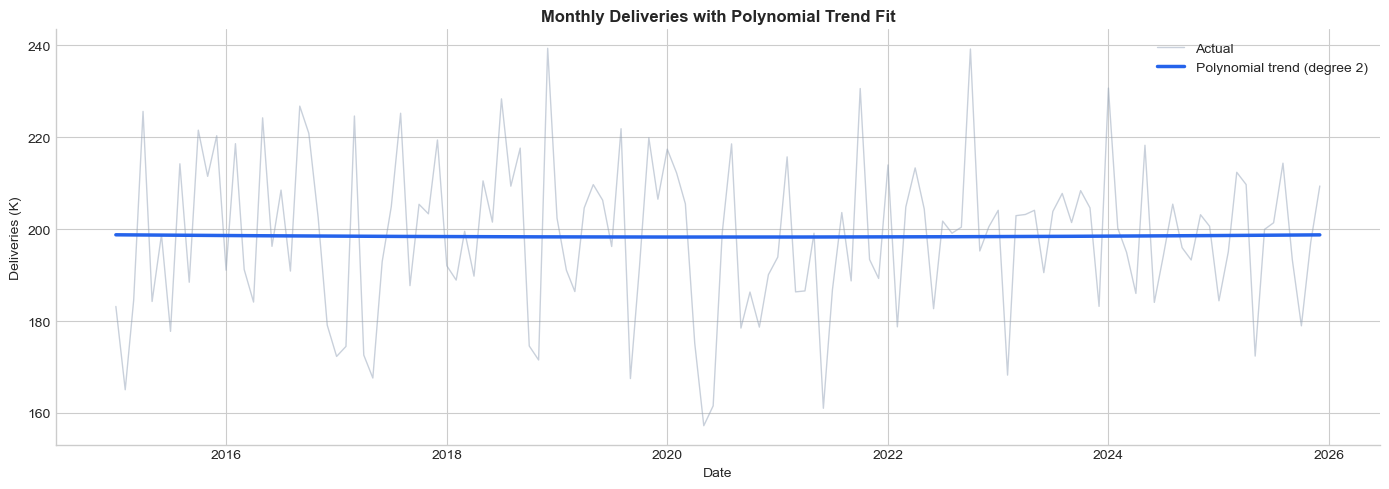

Trend R2 on historical data: 0.0001


In [20]:
degree = 2
coeffs   = np.polyfit(ts['t'], ts['Estimated_Deliveries'], degree)
ts['Trend'] = np.polyval(coeffs, ts['t'])

plt.figure(figsize=(14, 5))
plt.plot(ts['Period'], ts['Estimated_Deliveries']/1e3,
         alpha=0.5, color='#94A3B8', linewidth=1, label='Actual')
plt.plot(ts['Period'], ts['Trend']/1e3, color='#2563EB',
         linewidth=2.5, label=f'Polynomial trend (degree {degree})')
plt.title('Monthly Deliveries with Polynomial Trend Fit', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Deliveries (K)')
plt.legend()
plt.tight_layout()
plt.show()

trend_r2 = r2_score(ts['Estimated_Deliveries'], ts['Trend'])
print(f"Trend R2 on historical data: {trend_r2:.4f}")

### 7.3 12-Month Forecast (2026)

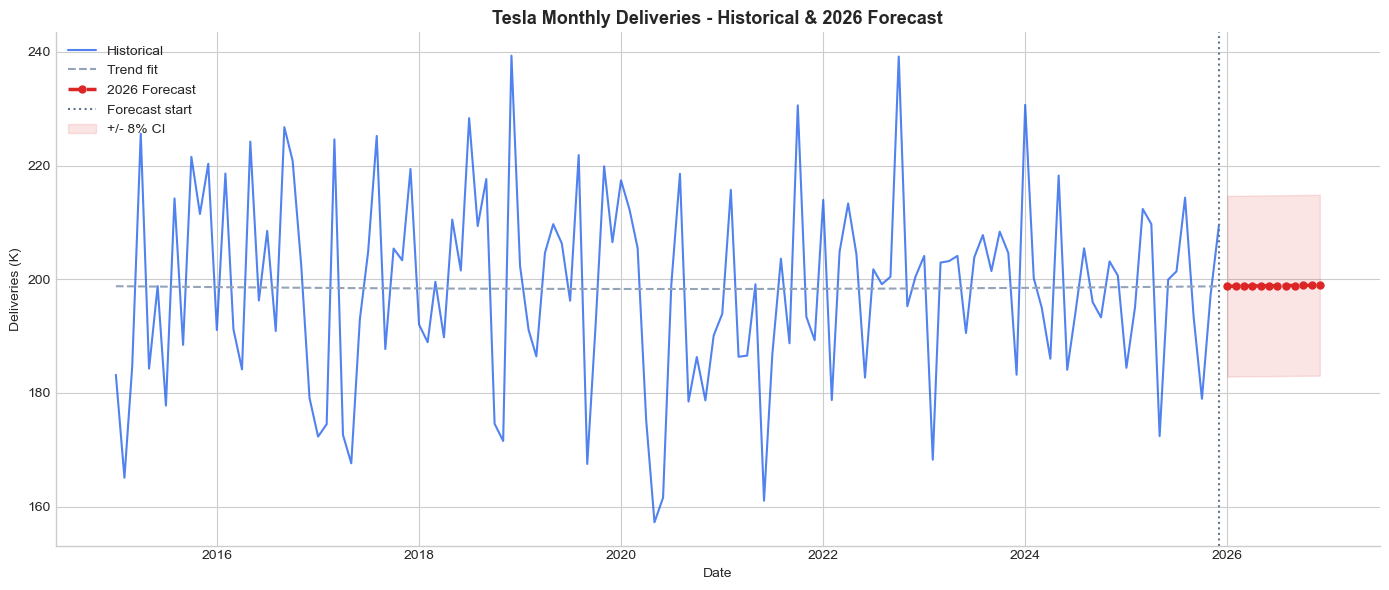

2026 Monthly Forecast:
    Period  Forecast
2026-01-01    198771
2026-02-01    198786
2026-03-01    198801
2026-04-01    198817
2026-05-01    198832
2026-06-01    198848
2026-07-01    198864
2026-08-01    198881
2026-09-01    198897
2026-10-01    198914
2026-11-01    198931
2026-12-01    198948


In [21]:
n_forecast    = 12
future_t      = np.arange(len(ts), len(ts) + n_forecast)
forecast_vals = np.polyval(coeffs, future_t)

last_year, last_month = ts['Year'].iloc[-1], ts['Month'].iloc[-1]
future_periods = []
for i in range(n_forecast):
    m = (last_month + i) % 12 + 1
    y = last_year + (last_month + i) // 12
    future_periods.append(pd.Timestamp(year=y, month=m, day=1))

forecast_df = pd.DataFrame({
    'Period': future_periods,
    'Forecast': forecast_vals.astype(int)
})

plt.figure(figsize=(14, 6))
plt.plot(ts['Period'], ts['Estimated_Deliveries']/1e3,
         color='#2563EB', linewidth=1.5, label='Historical', alpha=0.8)
plt.plot(ts['Period'], ts['Trend']/1e3,
         color='#94A3B8', linestyle='--', linewidth=1.5, label='Trend fit')
plt.plot(forecast_df['Period'], forecast_df['Forecast']/1e3,
         color='#DC2626', linewidth=2.5, marker='o', markersize=5,
         linestyle='--', label='2026 Forecast')
plt.axvline(ts['Period'].iloc[-1], color='#64748B', linestyle=':', linewidth=1.5,
            label='Forecast start')
plt.fill_between(forecast_df['Period'],
                 forecast_df['Forecast']/1e3 * 0.92,
                 forecast_df['Forecast']/1e3 * 1.08,
                 color='#DC2626', alpha=0.12, label='+/- 8% CI')
plt.title('Tesla Monthly Deliveries - Historical & 2026 Forecast', fontweight='bold', fontsize=13)
plt.xlabel('Date'); plt.ylabel('Deliveries (K)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("2026 Monthly Forecast:")
print(forecast_df.to_string(index=False))